In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [4]:
#load the dataset
df = pd.read_csv("../../processed_scaled.csv")

In [5]:

print(df.shape)
print(df.head())

(7043, 15)
   gender  SeniorCitizen  Dependents    tenure  PhoneService  MultipleLines  \
0       0              0           0 -1.277445             0              0   
1       1              0           0  0.351370             1              0   
2       0              0           1  0.799294             1              0   
3       0              0           0 -1.277445             1              0   
4       1              0           0  1.410099             1              0   

   Contract  MonthlyCharges  Churn  internet_fiber  TotalCharges  \
0         0       -1.321350      1           False     -0.995538   
1         1       -1.321350      0           False     -0.553953   
2         0       -1.520755      0           False     -0.570291   
3         1        0.373593      1           False     -0.973018   
4         0       -0.457261      0            True      0.502321   

   TenureGroup_13-24m  TenureGroup_25-48m  TenureGroup_49-72m  \
0               False               Fals

In [6]:
#checking duplication
print("Dataset Shape:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())

Dataset Shape: (7043, 15)
Duplicate Rows: 302


In [8]:
df=df.drop_duplicates()

In [9]:
#prepare features data
X = df.drop('Churn', axis=1)
print(X.shape)

(6741, 14)


In [10]:


# Store WCSS values
wcss = []

# Calculate WCSS for k = 1 to 10
for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Display WCSS values
print(wcss)

[37656.62517006368, 25838.52836876238, 22085.473144839143, 19569.9133007083, 17787.848929122978, 16463.930273972615, 15612.124239841378, 14795.134849706803, 14107.451688504196, 13497.987437783813]


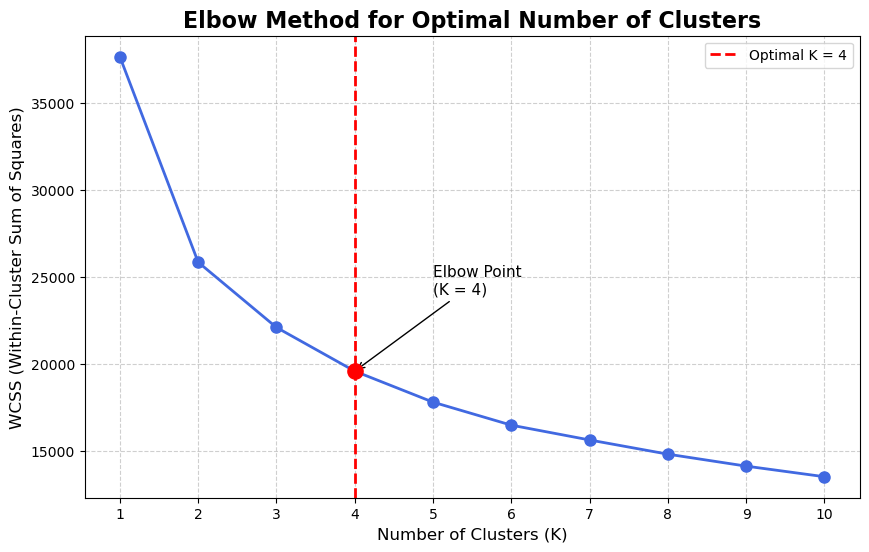

In [28]:


# Plot the Elbow Method
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 11),
    wcss,
    marker='o',
    markersize=8,
    linewidth=2,
    color='royalblue'
)

# Highlight the optimal cluster
optimal_k = 4
plt.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2,
            label=f'Optimal K = {optimal_k}')

plt.scatter(optimal_k, wcss[optimal_k-1], color='red', s=120, zorder=5)

plt.annotate(
    'Elbow Point\n(K = 4)',
    xy=(optimal_k, wcss[optimal_k-1]),
    xytext=(5, 24000),
    arrowprops=dict(facecolor='black', arrowstyle='->'),
    fontsize=11
)

plt.title("Elbow Method for Optimal Number of Clusters", fontsize=16, fontweight='bold')
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("WCSS (Within-Cluster Sum of Squares)", fontsize=12)

plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.6)

plt.legend()

#save the graph 
plt.savefig("Elbow_Method.png", dpi=300, bbox_inches="tight")


plt.show()

In [29]:


wcss_table = pd.DataFrame({
    'Number of Clusters (k)': range(1, 11),
    'WCSS': wcss
})

print(wcss_table)

   Number of Clusters (k)          WCSS
0                       1  37656.625170
1                       2  25838.528369
2                       3  22085.473145
3                       4  19569.913301
4                       5  17787.848929
5                       6  16463.930274
6                       7  15612.124240
7                       8  14795.134850
8                       9  14107.451689
9                      10  13497.987438


In [33]:

from sklearn.metrics import silhouette_score

print("Silhouette Scores for different K values:\n")

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)

    print(f"K = {k}: {score:.3f}")

Silhouette Scores for different K values:

K = 2: 0.286
K = 3: 0.208
K = 4: 0.208
K = 5: 0.204
K = 6: 0.200
K = 7: 0.183
K = 8: 0.182
K = 9: 0.180
K = 10: 0.184


In [31]:
# K-Means model with the selected number of clusters
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Fit the model and assign cluster labels
cluster_labels = kmeans.fit_predict(X)

# Calculate Silhouette Score
sil_score = silhouette_score(X, cluster_labels)

print(f"Silhouette Score: {sil_score:.3f}")

Silhouette Score: 0.208
